# Get starting with LangChain

This notebook was created when I was studying the LangChain library based in the book **Generative AI with LangChain, Second Edition** of the authors *Bean Aufffart* and *Leonid Kuligin*. The book is based on LangChain version 0.37, but this code is based on 1.2.10.

## Preparing the API to Google's Gemini

I only have an API key for Google's Gemini, so every example will run on that model or in local model. The file that configures needs to contain the following code:

```python
import os

GOOGLE_API_KEY = "..."

def set_environment():
    variable_dict = globals().items()

    for key, value in variable_dict:
        if "API" in key or "ID" in key or "GOOGLE" in key:
            os.environ[key] = value
```

I will not upload this file to not risk of leak my own API key. The file `config.py` is listed on `.gitignore`.

So, all you need to do is to run the following code to enable all the API keys required to this notebook.

In [1]:
# setting the environment variables, the keys
import sys
import os

from IPython.core.debugger import prompt
from langchain_core.messages import HumanMessage
from openai import project
from watchfiles import awatch

sys.path.insert(0, os.path.abspath('..'))

from config import set_environment
# for the keys - as explained early in chapter 2
set_environment()

## Run tasks on Google's Gemini

Here are simple codes that run simple tasks in Google's Gemini model:

In [3]:
from langchain_google_genai import GoogleGenerativeAI

gemini_pro = GoogleGenerativeAI(model="gemini-2.0-flash")

response = gemini_pro.invoke("Tell me a joke about Java Programming language.")
print(response)

Why did the Java developer wear glasses?

Because he didn't C#!


### Using Chat Templates

Here I will use chat templates objects to interact with the model.

In [6]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage

# Notice that the template configures 2 separated tuples, configuring two attributes: system and user.
template = ChatPromptTemplate.from_messages([
    ("system", "You are an experienced programmer and mathematical analyst."),
    ("user", "{problem}")
])

# Here I configure the custom Google chat object. Every object has properties to configure it.
chat = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash",
    max_output_tokens=400,
)

# Create a chain of invocations. Here it will invoke template and then chat
chain  = template | chat

problem = "Design an algorithm in R, using dplyr library, to clean a dataset of missing values."

# Notice that we invoke the chain
# response = chat.invoke([HumanMessage(content=problem)]) -> This is hwo we invoke directly in the chat object
response = chain.invoke({ "problem": problem })

print(response.content)

```R
# Algorithm: Clean a dataset of missing values using dplyr

# 1. **Understand the Data:**
#   - Inspect the dataset to identify columns with missing values (NAs).
#   - Determine the type of missingness (MCAR, MAR, MNAR).  This informs the choice of imputation method.
#   - Consider the impact of removing rows or columns with missing data.

# 2. **Define Strategies for Handling Missing Values:**
#   - **Removal:**
#     - Remove rows with any missing values (complete case analysis).  Use cautiously, as it can lead to significant data loss.
#     - Remove columns with a high percentage of missing values.  Define a threshold (e.g., >50% missing) for removal.
#   - **Imputation:**
#     - **Mean/Median Imputation:** Replace missing values with the mean or median of the column. Simple but can distort distributions and underestimate variance.  Suitable for MCAR data.
#     - **Mode Imputation:** Replace missing values with the most frequent value in the column.  Useful for categorical 

### Using LangChain Expression Language (LCEL)

LCEL helps us to create a chain of invocation when running tasks on models.

Here is a simple workflow using LCEL:

In [7]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI

# Create all the components that will be part of the chain of invocation
prompt = PromptTemplate.from_template("Tell me a joke about {topic}")
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash", max_output_tokens=400)
output_parser = StrOutputParser()

# Create the chain
chain = prompt | llm | output_parser

# Execute the workflow(chain) with a single call
result = chain.invoke({'topic': 'dogs'})
print(result)

Why did the dachshund get lost in the desert?

Because he went looking for a wiener!


Here is a more complex chain. In this new chain, we will invoke a model with the response of another task.

In [8]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.runnables import RunnablePassthrough

# Create all the components that will be part of the chain of invocation
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash")
output_parser = StrOutputParser()

# First chain: create a story
story_prompt = PromptTemplate.from_template("Write me a short story about {topic}")
story_chain  = story_prompt | llm | output_parser

# Second chain: analyze the story
analyze_story_prompt = PromptTemplate.from_template("Analyze the following story's mood:\n {story}")
analyze_story_chain  = story_prompt | llm | output_parser

# Combine both chains
# story_with_analyze_chain = story_chain | analyze_story_chain # This way we lost the story, just getting the resulting analysis.
story_with_analyze_chain = RunnablePassthrough.assign(story = story_chain).assign(analysis=analyze_story_chain)

story_with_analyze_result = story_with_analyze_chain.invoke({ "topic": "a raining day at school"})
print(story_with_analyze_result.keys())
print("\n\n Here is the story: \n", story_with_analyze_result["story"])
print("\n\n Here is the analysis: \n", story_with_analyze_result["analysis"])

dict_keys(['topic', 'story', 'analysis'])


 Here is the story: 
 The sky was a bruised plum color when the first fat drops splattered against the classroom window. Inside, Mrs. Gable was droning on about the French Revolution, but outside, a real revolution was brewing. The rain, initially tentative, quickly escalated into a downpour, drumming a furious rhythm against the pane.

Twelve-year-old Maya, usually a diligent note-taker, found herself captivated. The world outside was a blurry, watery painting. The oak tree in the courtyard was a shivering silhouette, and the normally bustling parking lot was a shimmering, distorted lake.

A collective sigh rippled through the classroom. The rain meant no outdoor recess, no kickball, no chasing each other around the playground. A collective groan escaped as Mrs. Gable announced, “Well, children, looks like we’ll be having indoor recess today.”

The energy in the room shifted. Some students grumbled, others huddled in groups to plan their ind

## LangChain Fundamentals

### State Management

#### Creating a simple LangGraph

Fist step to handle state management, I need to create a object that handle the state. In this case, I will use a object called *JobApplicationState*, to handle a task related to job application, dã.

In [9]:
from typing_extensions import TypedDict

class JobApplicationState(TypedDict):
    job_description: str
    is_suitable: bool
    application: str

Now I will create a state graph using LangGraph. Notice that for each node, I create a function:

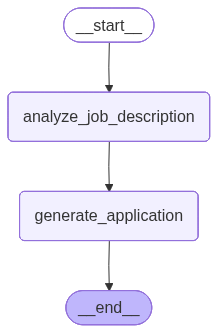

In [10]:
from langgraph.graph import StateGraph, START, END

def analyze_job_description(state):
    """
    Notice that the method return a JSON with the attribute is_suitable
    filled with True/False based in the length of the job_description
    variable.
    """
    print("...Analyzing a provided job description ...")
    return {"is_suitable": len(state["job_description"]) > 100}

def generate_application(state):
    """
    Generate a JSON with a fake application name.
    """
    print("...generating application...")
    return {"application": "some_fake_application"}

# Now let's create the StateGraph.
builder = StateGraph(JobApplicationState)

# The nodes added are exactly the function that was created before.
builder.add_node("analyze_job_description", analyze_job_description)
builder.add_node("generate_application", generate_application)

# The edges are like connections between nodes.
builder.add_edge(START, "analyze_job_description")
builder.add_edge("analyze_job_description", "generate_application")
builder.add_edge("generate_application", END)

# A graph is a StateGraph compiled, after all the configuration.
graph = builder.compile()

# We can visualize the graph with this code:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

Let's run a fake application request (notice that since the job_description length is < 100, the is_suitable variable will be false:

In [11]:
response = graph.invoke({"job_description": "fake_jd"})
print(response)

...Analyzing a provided job description ...
...generating application...
{'job_description': 'fake_jd', 'is_suitable': False, 'application': 'some_fake_application'}


#### Create a conditional edge in LangGraph

This time I will create a conditional edge in the graph.

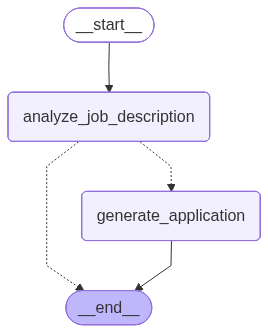

In [12]:
from typing import Literal, Annotated

# Now let's create the StateGraph.
builder = StateGraph(JobApplicationState)

# The nodes added are exactly the function that was created before.
builder.add_node("analyze_job_description", analyze_job_description)
builder.add_node("generate_application", generate_application)

def is_suitable_condition(state: JobApplicationState) -> Literal["generate_application", END]:
    """
    This edge condition returns  "generate_application" if the is_suitable equals True, or
    END if the is_suitable equals False.
    Notice that all the possible returns are listed in the return type
    """
    if state.get("is_suitable"):
        return "generate_application"
    return END

# The edges are like connections between nodes. Notice that the seconde edge is a conditional one
builder.add_edge(START, "analyze_job_description")
builder.add_conditional_edges("analyze_job_description", is_suitable_condition)
builder.add_edge("generate_application", END)

# A graph is a StateGraph compiled, after all the configuration.
graph = builder.compile()

# We can visualize the graph with this code:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


Notice that the rendered graph picture is missing a dotted line from analyze_job_description to END. Maybe this is a bug of the library versions that I'm using here.

In [13]:
response = graph.invoke({"job_description": "fake_jd"})
print(response)

...Analyzing a provided job description ...
{'job_description': 'fake_jd', 'is_suitable': False}


## Chain of Thoght

This type of feature engineering the model generate intermediate step-by-step reasoning.

Here is a simple example:

In [14]:
from langchain_classic import hub

# Use a Chaing of Thought already created, it can be found on LangSmith Hub in this address https://smith.langchain.com/hub/arietem/math_cot
math_cot_prompt = hub.pull("arietem/math_cot")
cot_chain = math_cot_prompt | llm | StrOutputParser()

print(cot_chain.invoke("Solve equation 2*x+5=15"))


Answer: Let's think step by step
2*x + 5 = 15
2*x = 15 - 5
2*x = 10
x = 10 / 2
x = 5
<answer>5</answer>


Here is a complete COT example:

In [15]:
from operator import itemgetter

# The template give us 2 placeholders: question and full_answer, which will be answered the same way as the previous example
parse_prompt_template = (
    "Given the initial question and a full answer, "
    "extract the concise answer. Do not assume anything and "
    "only use a provided full answer. \n\n QUESTION:\n{question}\n"
    "FULL ANSWER:\n{full_answer}\n\nCONCISE ANSWER:\n"
)

parse_prompt = PromptTemplate.from_template(parse_prompt_template)

# The chain call the 'cot_chain' generated in the previous example.
final_chain = (
    {
        "full_answer" : itemgetter("question") | cot_chain,
        "question"    : itemgetter("question"),
    } |
    parse_prompt | llm | StrOutputParser()
)

# It will only return a concise answer.
print(final_chain.invoke({"question" : "Solve equation 2*x+5=15"}))

5


## Map-Reduce to summarize a long video

Here I am building a LangGraph that implements a Map-Reduce to summarize a long video. This summarization is done to avoid working with long context windows, that can be an issue in some models.

The first step is to model de LangGraph state objects:

In [17]:
from langgraph.types import Send
from typing_extensions import TypedDict
from typing import Annotated

import operator

class AgentState(TypedDict):
    video_uri: str
    chunks: int
    interval_secs: int
    summaries: Annotated[list, operator.add]
    final_summary: str

class _ChunkState(TypedDict):
    video_uri: str
    start_offset: int
    interval_secs: int

This second part initialize the objects and the chain.

In [19]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_vertexai import ChatVertexAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

reduce_prompt = PromptTemplate.from_template(
    "You are given a list of summaries that "
    "of a video splitted into sequential pieces.\n"
    "SUMMARIES:\n{summaries}"
    "Based on that, prepare a summary of a whole video."
)

llm = ChatVertexAI(model="gemini-2.0-flash")

/var/folders/8c/k0d1bjq91qb_m_1nbm26xh500000gn/T/ipykernel_67325/2252268429.py:13: DeprecationWarning: Use [`ChatGoogleGenerativeAI`][langchain_google_genai.ChatGoogleGenerativeAI] instead.
  llm = ChatVertexAI(model="gemini-2.0-flash")
/var/folders/8c/k0d1bjq91qb_m_1nbm26xh500000gn/T/ipykernel_67325/2252268429.py:13: LangChainDeprecationWarning: The class `ChatVertexAI` was deprecated in LangChain 3.2.0 and will be removed in 4.0.0. An updated version of the class exists in the `langchain-google-genai package and should be used instead. To use it run `pip install -U `langchain-google-genai` and import as `from `langchain_google_genai import ChatGoogleGenerativeAI``.
  llm = ChatVertexAI(model="gemini-2.0-flash")
/opt/homebrew/Caskroom/miniconda/base/envs/langchain_ai/lib/python3.12/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "

Now, I created the graph functions that will act as nodes:

In [20]:
human_part = { "type": "text", "text": "Provide a summary of the video." }

def _create_input_messages(*, video_uri: str, chunks: int = 5, interval_secs: int = 600):
    """
    This function creates the input message with the video URL to the LLM
    :param video_uri: The video URI
    :param chunks: The number of chunks
    :param interval_secs: The interval in seconds for each chunk
    :return: a list with multiple HumanMessage objects for each chunk.
    """
    video_parts = []
    for start_offset in range(chunks):
        part = {
            "type": "media", "file_uri": video_uri, "mime_type": "video/mp4",
            "video_metadata": {
               "start_offset": {"seconds": start_offset*interval_secs},
                "end_offset": {"seconds": (start_offset+1)*interval_secs}}
        }
        video_parts.append(part)

    return [[HumanMessage(content=[human_part, vp])] for vp in video_parts]

async def _summarize_video_chunk(state: _ChunkState):
    """
    This function calls the LLM to summarize the video chunk
    """
    start_offset  = state["start_offset"]
    interval_secs = state["interval_secs"]
    video_part = {
        "type": "media",
        "file_uri": state["video_uri"],
        "mime_type": "video/mp4",
        "video_metadata": {
            "start_offset": {"seconds": start_offset*interval_secs},
            "end_offset"  : {"seconds": (start_offset+1)*interval_secs},
        }
    }
    response = await llm.ainvoke([HumanMessage(content=[human_part, video_part])])

    return { "summaries" : [response.content]}

def _merge_summaries(summaries: list[str], interval_secs: int = 600, **kwargs) -> str:
    """
    This function merges summaries into a single string
    :param summaries: list of chunk summary
    :param interval_secs: the interval in seconds for the chunks
    :param kwargs:
    :return: a merged string with all the chunk summaries
    """
    sub_summaries = []
    for i, summary in enumerate(summaries):
        sub_summary = (
            f"Summary from sec {i*interval_secs} to sec {(i+1)*interval_secs}:"
            f"\n{summary}\n"
        )
        sub_summaries.append(sub_summary)

    return "".join(sub_summaries)

async def _generate_final_summary(state: AgentState):
    """This function generates the final summary of all the video chunks summaries"""
    summary = _merge_summaries(
        summaries=state["summaries"], interval_secs=state["interval_secs"]
    )
    final_summary = await (reduce_prompt | llm | StrOutputParser()).ainvoke({"summaries": summary})

    return {"final_summary": final_summary}

def _map_summaries(state: AgentState):
    """ This function maps summaries into chunks """
    chunks = state["chunks"]

    payloads = [
        {
            "video_uri": state["video_uri"],
            "interval_secs": state["interval_secs"],
            "start_offset": 1
        } for i in range(state["chunks"])
    ]

    return [Send("summarize_video_chunk", payload) for payload in payloads]

Finally, I created the final graph to invoke the LLM:

This code only works if you use the `ChatVertexAI` chat, because of the error bellow:

~~~
ValueError: Unknown field for VideoMetadata: start_offset
~~~

The error above happens because the the class `ChatGoogleGenerativeAI` uses a old version of the class `VideoMetadata`, which not contains the **start_offset** and **end_offset** variables.

In [21]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(AgentState)

# Add the nodes to the graph
graph.add_node("summarize_video_chunk", _summarize_video_chunk)
graph.add_node("generate_final_summary", _generate_final_summary)

## Add the edges
graph.add_conditional_edges(START, _map_summaries, ["summarize_video_chunk"])
graph.add_edge("summarize_video_chunk", "generate_final_summary")
graph.add_edge("generate_final_summary", END)

app = graph.compile()

## Print the graph
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

## Some random video form youtube
video_uri = "https://www.youtube.com/watch?v=QfAEFo-zr5c"

result = await app.ainvoke(
    {"video_uri": video_uri, "chunks": 5, "interval_secs": 600},
    {"max_concurrency": 3}
)

print(result["final_summary"])

/opt/homebrew/Caskroom/miniconda/base/envs/langchain_ai/lib/python3.12/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


This video features a discussion, primarily by one commentator, about truth, lies, and individual opinions, specifically in the context of Brazilian politics and the Lula administration.

The commentator emphasizes that his actions are motivated by the "defense of the truth," combatting lies and fake news he attributes to certain groups. He asserts his independence from Pedro Ivo, stating he doesn't consider Ivo a leader and that Ivo's opinions, or anyone else's, will not influence his work. While acknowledging Ivo's recent "awakening" to the truth and the good work he does, the speaker refutes the idea that Ivo is a pioneer in the fight against fake news, giving that credit to Merlin das Trevas.

The commentator addresses accusations that he incites violence, particularly regarding his stance on the "dismantling" of the PT (Workers' Party) to create a new political force. He clarifies that this is not an incitement of homicide. He is critical of individuals spreading fake news against